<a href="https://colab.research.google.com/github/trevqxs/Trevor_INFO4670_Fall2026/blob/main/Assignment3_AssociationRuleMining_Template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3 — Association Rule Mining

**Dataset:** `bread_basket.csv` (11569 transactions)

Fill in the short answer cells and run the code cells. This notebook generates the required tables and figures.

**Sections:**
1. Setup & Data Load
2. EDA (a–e)
3. Frequent Itemset Mining (FP-Growth)
4. Association Rules + Report Table
5. Rule Subgraph (Bread, Coffee, Cake, Tea)
6. Interpretation Prompt


## 1) Setup & Data Load (10 pts)
- Place `bread_basket.csv` in the same folder as this notebook **or** update the path below.
- Needed packages: `pandas`, `matplotlib`, `mlxtend`, `networkx` (for the small graph).
- If a package is missing, run the `pip install` cell.

In [7]:
import pandas as pd

df = pd.read_csv('bread_basket.csv')

## 2) EDA (a–e) (30 pts)
### a) List variables and their dtypes (5 pts)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20507 entries, 0 to 20506
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   transaction      20507 non-null  int64 
 1   item             20507 non-null  object
 2   date_time        20507 non-null  object
 3   time             20507 non-null  object
 4   period_day       20507 non-null  object
 5   weekday_weekend  20507 non-null  object
dtypes: int64(1), object(5)
memory usage: 961.4+ KB


### b) "Statistics" overview (5 pts)
Use `describe(include='all')` as a stand‑in for Statistics.

In [9]:
display(df.describe(include='all'))

,transaction,item,date_time,time,period_day,weekday_weekend
count,20507.000000,20507,20507,20507,20507,20507
unique,NaN,94,159,1255,4,2
top,NaN,Coffee,2017-02-04,11:06,afternoon,weekday
freq,NaN,5471,292,52,11569,12807
mean,4976.202370,NaN,NaN,NaN,NaN,NaN
std,2796.203001,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN
25%,2552.000000,NaN,NaN,NaN,NaN,NaN
50%,5137.000000,NaN,NaN,NaN,NaN,NaN
75%,7357.000000,NaN,NaN,NaN,NaN,NaN


### c) Bar plot — count of **unique transactions per item** (10 pts)
Set the subtitle to your **FirstName LastName**.

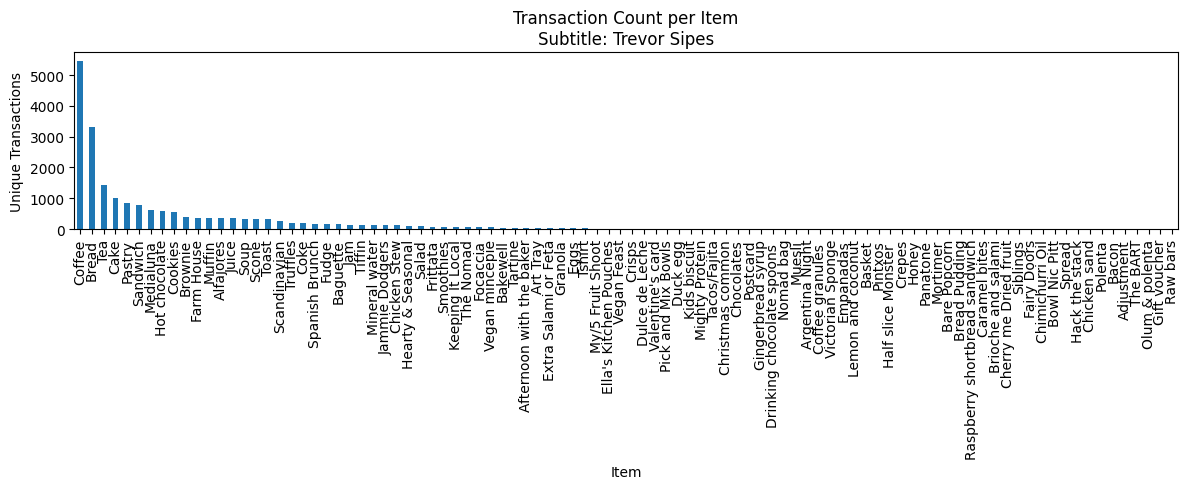

In [25]:
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore', category=DeprecationWarning)

subtitle = "Trevor Sipes"
item_counts = df['item'].value_counts() \
                .sort_values(ascending=False)

ax = item_counts.plot(kind='bar', figsize=(12,5))
plt.title(f"Transaction Count per Item\nSubtitle: {subtitle}")
plt.xlabel("Item"); plt.ylabel("Unique Transactions")
plt.tight_layout()
plt.show()

### d) Report counts for Coffee, Tea, Alfajores, Juice, and Chicken Stew (10 pts)

In [20]:
warnings.filterwarnings('ignore', category=DeprecationWarning)

items_to_report = ['Coffee', 'Tea', 'Alfajores', 'Juice', 'Chicken Stew']
item_counts = df[df['item'].isin(items_to_report)]['item'].value_counts()
display(item_counts)

,count
item,
Coffee,5471
Tea,1435
Juice,369
Alfajores,369
Chicken Stew,123


## 3) Frequent Itemset Mining with FP‑Growth (min_support = 0.02) (20 pts)
We pivot the data to a **transaction × item** one‑hot table (boolean), then run FP‑Growth.

In [21]:
from mlxtend.frequent_patterns import fpgrowth
from mlxtend.preprocessing import TransactionEncoder

warnings.filterwarnings('ignore', category=DeprecationWarning)

transactions = df.groupby('transaction')['item'].apply(list).values

te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

frequent_itemsets = fpgrowth(df_encoded, min_support=0.02, use_colnames=True)

display(frequent_itemsets.sort_values(by='support', ascending=False))

,support,itemsets
5,0.478394,(Coffee)
0,0.327205,(Bread)
8,0.142631,(Tea)
12,0.103856,(Cake)
19,0.090016,"(Coffee, Bread)"
6,0.086107,(Pastry)
13,0.071844,(Sandwich)
7,0.061807,(Medialuna)
2,0.058320,(Hot chocolate)
28,0.054728,"(Coffee, Cake)"


## 4) Association Rules + Report Table (30 pts)
(metric = confidence, min_threshold = ?) Please find a suitable min_threshold

In [22]:
from mlxtend.frequent_patterns import association_rules

warnings.filterwarnings('ignore', category=DeprecationWarning)

rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)

rules = rules.sort_values(by=['confidence', 'lift'], ascending=[False, False])

display(rules)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
7,(Toast),(Coffee),0.033597,0.478394,0.023666,0.704403,1.472431,1.0,0.007593,1.764582,0.332006,0.048464,0.433293,0.376936
3,(Medialuna),(Coffee),0.061807,0.478394,0.035182,0.569231,1.189878,1.0,0.005614,1.210871,0.170091,0.069665,0.174148,0.321387
2,(Pastry),(Coffee),0.086107,0.478394,0.047544,0.552147,1.154168,1.0,0.006351,1.164682,0.146161,0.091968,0.141396,0.325764
4,(Juice),(Coffee),0.038563,0.478394,0.020602,0.534247,1.116750,1.0,0.002154,1.119919,0.108738,0.041507,0.107078,0.288656
6,(Sandwich),(Coffee),0.071844,0.478394,0.038246,0.532353,1.112792,1.0,0.003877,1.115384,0.109205,0.074701,0.103448,0.306150
5,(Cake),(Coffee),0.103856,0.478394,0.054728,0.526958,1.101515,1.0,0.005044,1.102664,0.102840,0.103745,0.093105,0.320679
1,(Cookies),(Coffee),0.054411,0.478394,0.028209,0.518447,1.083723,1.0,0.002179,1.083174,0.081700,0.055905,0.076787,0.288707
0,(Hot chocolate),(Coffee),0.058320,0.478394,0.029583,0.507246,1.060311,1.0,0.001683,1.058553,0.060403,0.058333,0.055314,0.284542


## 5) Rule Subgraph (Bread, Coffee, Cake, Tea) (10 pts)

Let's visualize the association rules involving 'Bread', 'Coffee', 'Cake', and 'Tea' using a directed graph. This helps in understanding the relationships between these key items.

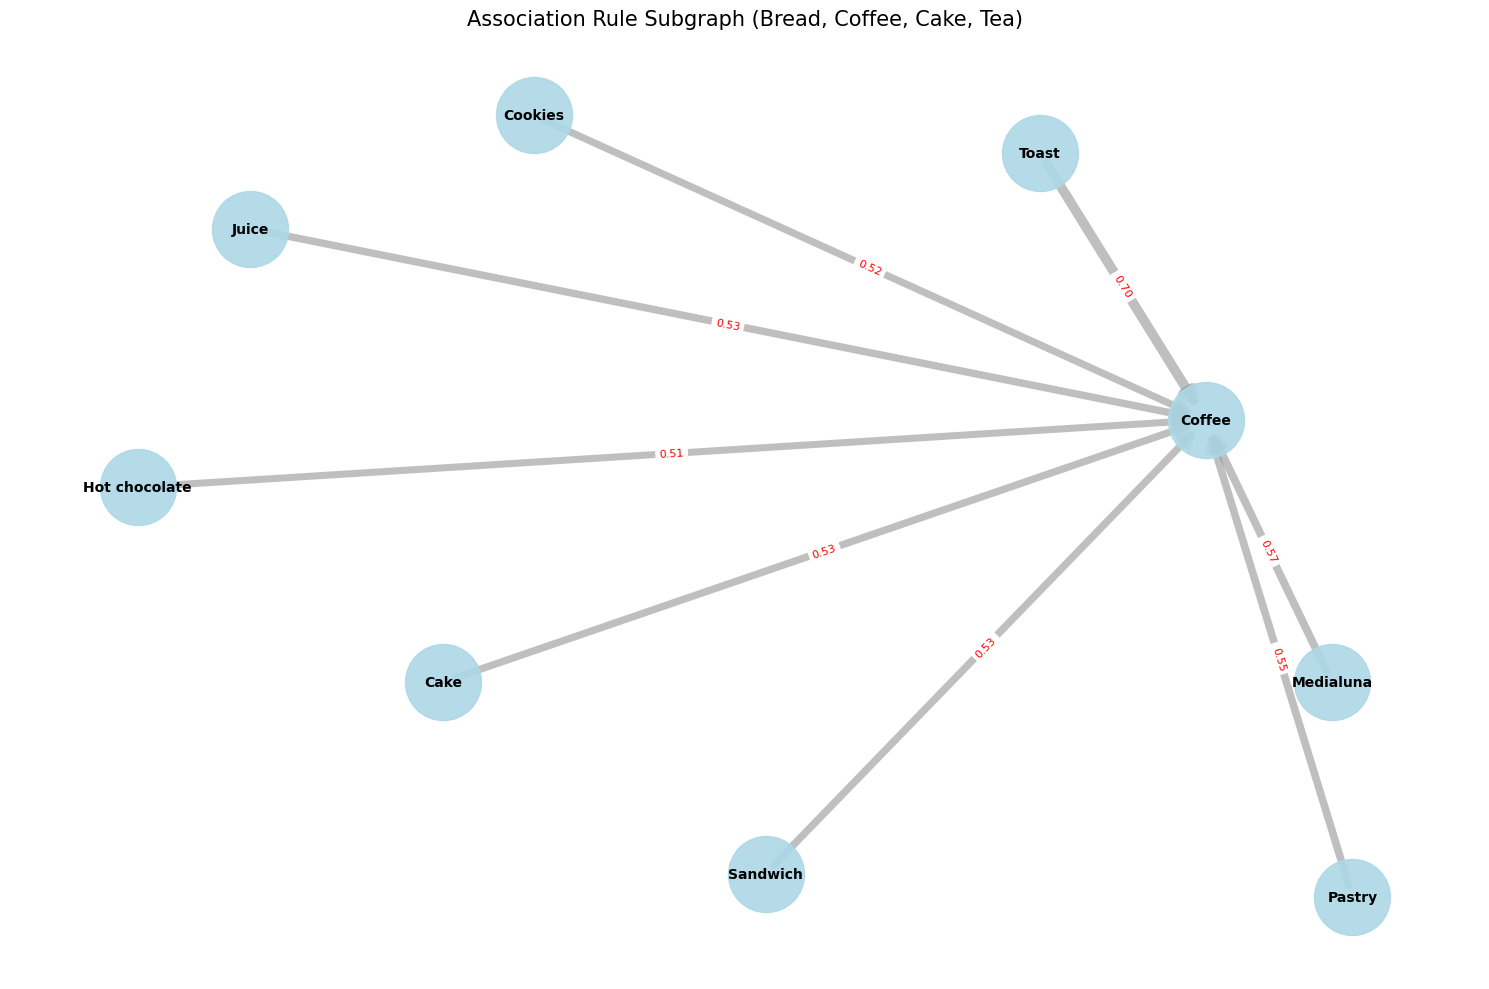

In [23]:
import networkx as nx
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore', category=DeprecationWarning)

relevant_items = {'Bread', 'Coffee', 'Cake', 'Tea'}
filtered_rules = rules[
    rules['antecedents'].apply(lambda x: any(item in x for item in relevant_items)) |
    rules['consequents'].apply(lambda x: any(item in x for item in relevant_items))
]

G = nx.DiGraph()

for index, row in filtered_rules.iterrows():
    antecedent = ', '.join(list(row['antecedents']))
    consequent = ', '.join(list(row['consequents']))
    confidence = row['confidence']
    lift = row['lift']

    if antecedent not in G:
        G.add_node(antecedent, type='antecedent')
    if consequent not in G:
        G.add_node(consequent, type='consequent')

    G.add_edge(antecedent, consequent, weight=confidence, lift=lift)

fig = plt.figure(figsize=(15, 10))
pos = nx.spring_layout(G, k=0.8, iterations=50)

nx.draw_networkx_nodes(G, pos, node_size=3000, node_color='lightblue', alpha=0.9)

weights = [G[u][v]['weight'] for u, v in G.edges()]
nx.draw_networkx_edges(G, pos, width=[w*10 for w in weights], alpha=0.5, edge_color='gray', arrowsize=20)

nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

edge_labels = {(u, v): f"{G[u][v]['weight']:.2f}" for u, v in G.edges()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red', font_size=8)

plt.title('Association Rule Subgraph (Bread, Coffee, Cake, Tea)', size=15)
plt.axis('off')
plt.tight_layout()
plt.show()

The rule Coffee, Cake ⇒ Bread means that if a customer buys Coffee and Cake, they are likely to also buy Bread.

-   **Support**: To calculate the support for Coffee, Cake, Bread, we would look at the support column of the frequent itemsets for the itemset containing all three. If, for example, the support is 0.005, it means that 0.5% of all transactions contain Coffee, Cake, and Bread together.

-   **Confidence**: This metric is for the rule Coffee, Cake ⇒ Bread. If the confidence is, say, 0.60, it means that among all transactions where Coffee and Cake are purchased together, 60% of those transactions also include Bread.

-   **Lift > 1**: A lift value greater than 1 implies a positive association between the items in the antecedent Coffee, Cake and the consequent Bread. For example, if the lift is 1.2, it means that customers who buy Coffee and Cake are 1.2 times more likely to buy Bread than customers in general. This suggests that the purchase of Coffee and Cake "lifts" the probability of purchasing Bread.

>